## What should we expect as agreement between models?

In [1]:
import torch
from functools import reduce
from operator import mul, add
import itertools
import more_itertools

In [2]:
# get a set in N positive instances
N = 1_000_000
labels = torch.ones(size=(N,))

In [3]:
# models
M = 10
fn_rates = torch.randint(low=6, high=10 + 1, size=(M,)) / 10
# for the calculation, ensure FNR are never exactly 0.0 or 1.0
epsilon = 0.0001
fn_rates = [r + (epsilon * (r == 0)) - (epsilon * (r == 1)) for r in fn_rates]
fn_rates

[tensor(0.9000),
 tensor(0.8000),
 tensor(0.8000),
 tensor(0.8000),
 tensor(0.9000),
 tensor(0.9000),
 tensor(0.9000),
 tensor(0.9999),
 tensor(0.7000),
 tensor(0.7000)]

In [4]:
# check with observed FNR
# M = 18
# fn_rates = [ #ACS Income
#     0.13690330377410873,
#     0.21681119657700912,
#     0.15571668871360214,
#     0.40079695588979797,
#     0.4184508353338886,
#     0.9080561135335522,
#     0.3222445413420868,
#     0.05854686198618392,
#     0.9999673378733689,
#     0.4987506736563618,
#     0.06258063462512044,
#     0.12006597749579476,
#     0.0849378603040844,
#     0.06769225744288211,
#     0.24548854375908416,
#     0.13041987163784233,
#     0.9271471265494097,
#     0.21811768164225173,
# ]
# M = 10
# fn_rates = [ #ACS Public Coverage
#     0.48229372111506874,
#     0.6804333107650643,
#     0.9790409466898237,
#     0.9717994760236672,
#     0.8740101851579288,
#     0.6165552971652292,
#     0.5712813870654382,
#     0.7673015218863148,
#     0.5424332518913191,
#     0.8099849871949604,
# ]

### Simulate model predictions

In [5]:
def biased_coin(num_flips, bias):
    return (torch.rand(size=(num_flips,1)) >= bias).int()

In [6]:
predictions = torch.concat([biased_coin(N,fn_rates[i]) for i in range(M)], dim=1)
predictions

tensor([[0, 0, 0,  ..., 0, 1, 0],
        [0, 0, 0,  ..., 0, 0, 1],
        [0, 0, 0,  ..., 0, 1, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [7]:
model_agreement_0 = M - predictions.sum(axis=1)
model_agreement_0

tensor([ 8,  9,  7,  ...,  9,  9, 10])

In [8]:
values, counts = model_agreement_0.unique(return_counts=True)
values, counts/N

(tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
 tensor([1.0000e-06, 7.8000e-05, 1.1430e-03, 8.6620e-03, 4.4415e-02, 1.4627e-01,
         2.9717e-01, 3.3753e-01, 1.6473e-01]))

### Compute Agreement

In [9]:
def expected_agreement(fn_rates, k, epsilon=0.0001):
    M = len(fn_rates)
    fn_rates = [
        r + (epsilon * (r == 0)) - (epsilon * (r == 1)) for r in fn_rates
    ]  # make sure none of the rates is exactly 0 or 1
    # creat initial list to indicate which model rejects
    rej_indicators = torch.concat(
        [torch.ones(k, dtype=int), torch.zeros(M - k, dtype=int)]
    ).tolist()
    # get all unique permutations of k rejections
    unique_permutations = more_itertools.distinct_permutations(rej_indicators)

    products = []
    for indices in unique_permutations:
        # for each permutations, compute the product of fnrs
        products.append(
            reduce(
                mul,
                [
                    p ** indices[i] * (1 - p) ** (1 - indices[i])
                    for i, p in enumerate(fn_rates)
                ],
            )
        )
    # sum over all permutations
    return reduce(add, products)

In [10]:
probs_expected = []
for k in range(M+1):
    rej_indicators = torch.concat([torch.ones(k, dtype=int), torch.zeros(M-k, dtype=int)])
    rej_indicators.tolist()
    terms = []
    for indices in more_itertools.distinct_permutations(rej_indicators):
        #print(indices, type(indices[0]))
        tmp = [p**indices[i] * (1-p)**(1-indices[i]) for i, p in enumerate(fn_rates)]
        #print(tmp)
        terms.append(reduce(mul, tmp))
        #print(terms[-1])
    probs_expected.append(reduce(add, terms))
probs_expected

[tensor(7.2012e-12),
 tensor(7.2372e-08),
 tensor(3.8002e-06),
 tensor(8.6174e-05),
 tensor(0.0011),
 tensor(0.0088),
 tensor(0.0447),
 tensor(0.1464),
 tensor(0.2967),
 tensor(0.3377),
 tensor(0.1646)]

### Visual Inspection

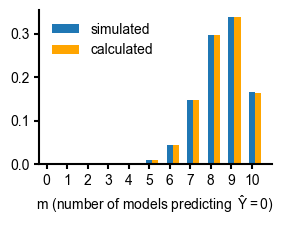

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl


plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

plt.figure(figsize=(3,2))
width=0.3
plt.bar(values, counts/N, width=width, label='simulated')
plt.bar(torch.arange(0,M+1)+width, probs_expected, color='orange', width=width, label='calculated')
plt.xticks(torch.arange(0,M+1))
plt.xlabel("$m$ (number of models predicting $\hat{\,Y}=0$)")
plt.legend()
# plt.ylabel("fraction of positive instances")
plt.show()